In [1]:
import os 
import torch 
from torch import nn 
from torchvision.datasets import MNIST 
from torch.utils.data import DataLoader 
from torchvision import transforms 
import numpy as np 
import matplotlib.pyplot as plt 
import uuid

In [2]:
number_of_epochs = 5

noise_dimension = 50
batch_size = 128
train_on_gpu = True
unique_run_id = str(uuid.uuid4())
print_stats_after_n_th_batch = 200         #print the stats after nth batch 
lr = 0.0002
optimizer_betas = (0.5, 0.999) 
generator_output_shape = 28*28*1


code to speed up PyTorch 

In [3]:
torch.autograd.set_detect_anomaly(False)
torch.autograd.profiler.profile(False)
torch.autograd.profiler.emit_nvtx(False)
torch.backends.cudnn.benchmark = True

generator module 


In [4]:
class Generator(nn.Module):
    
    def __init__(self,):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(noise_dimension, 128, bias = False),
            nn.BatchNorm1d(128, 0.8),
            nn.LeakyReLU(0.25),
            nn.Linear(128, 256, bias = False), 
            nn.BatchNorm1d(256, 0.8), 
            nn.LeakyReLU(0.25),
            nn.Linear(256, 512, bias = False),
            nn.BatchNorm1d(512,0.8), 
            nn.LeakyReLU(0.25),
            #final upsampling
            nn.Linear(512, generator_output_shape, bias = False), 
            nn.Tanh()
        ) 
    
    def forward(self, x): 
        """forward pass"""
        return self.layers(x)

discriminator module

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(generator_output_shape, 1024),
            nn.LeakyReLU(0.25), 
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.25),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.25),
            nn.Linear(256,1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        """forward pass"""
        return self.layers(x)

HOUSEKEEPING FUCTIONS

In [6]:
def get_device():
    return torch.device("cuda:0" if torch.cuda.is_available() and train_on_gpu else 'cpu') 

def make_directory_for_run():
    print(f'preparing training run {unique_run_id}')
    if not os.path.exists('./runs'):
        os.mkdir('./runs')
    os.makedirs(f'./runs/{unique_run_id}', exist_ok = True) # this line generated error for reruns after first try which got erros
    # os.mkdir(f'./runs/{unique_run_id}') # this line generated error for reruns after first try which got erros

In [7]:
def generate_image(generator, epoch = 0, batch = 0, device =  get_device()):
    image = []
    noise = generate_noise(batch_size, device = device )
    generator.eval()
    images = generator(noise)
    plt.figure(figsize = (10, 10))
    for i in range(16):
        #get image 
        image = images[i]
        #convert image back onto CPU and reshape 
        image = image.cpu().detach().numpy()
        image = np.reshape(image, (28,28))
        #plot
        plt.subplot(4,4, i+1)
        plt.imshow(image, cmap = 'gray')
        plt.axis('off')
    if not os.path.exists(f'./runs/{unique_run_id}/images'):
        os.mkdir(f'./runs/{unique_run_id}/images')
    plt.savefig(f'./runs/{unique_run_id}/images/epoch{epoch}_batch{batch}.jpg')
    

In [8]:
def save_models (generator, discriminator, epoch):
    "save models at specific point in time "
    torch.save(generator.state_dict(), f'./runs/{unique_run_id}/generator_{epoch}.pth')
    torch.save(discriminator.state_dict(),f'./runs/{unique_run_id}/discriminator_{epoch}.pth')

In [9]:
def print_training_progress(batch, generator_loss, discriminator_loss):
    """print training progress"""
    print("Losses after mini-batch %5d: generator %e, discriminator %e"%(batch,generator_loss,discriminator_loss))


preparing the data sets 

In [10]:
def prepare_datasets():
    dataset = MNIST(os.getcwd(), download = True, train= True, transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])) 

#batch and shuffle data 
    trainloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, num_workers=4, pin_memory= True)
    return trainloader


initialization functions for joint training process

here we initialize generator and discriminator, move them to configured device, and then return it. 
- initializing binary cross-entropy loss in initalize_loss
- initialize optimizer for both generator and discriminator in initialize_optimizers

In [11]:
def initialize_models(device = get_device()):
    generator = Generator()
    discriminator = Discriminator()
    generator.to(device)
    discriminator.to(device)
    #RETURN MODELS  
    return generator, discriminator 

def initialize_loss():
    return nn.BCELoss()

def initialize_optimizers(generator, discriminator):
    generator_optimizer = torch.optim.AdamW(generator.parameters(), lr = lr, betas = optimizer_betas)
    discriminator_optimizer = torch.optim.AdamW(discriminator.parameters(), lr = lr, betas = optimizer_betas)
    return generator_optimizer, discriminator_optimizer


next is forward and backward pass through the NNs

- we need three defs for this and whole training process 
    - generate_noise used to generate number_of_images noise vectors of noise_dimension,  onto the device that you configured earlier

    - efficiently zeroing the gradients at start of each training step by calling efficient_zero_grad()
    
    - finally compute forward_and_backward pass, by using some model, loss function, data and corresponding targets. The numeric value for loss is then returned   

In [12]:
def generate_noise(number_of_images = 1, noise_dimension = noise_dimension, device = None):
    return torch.randn(number_of_images, noise_dimension, device = device)

def efficient_zero_grad(model):
    for param in model.parameters():
        param.grad = None 
        
def forward_and_backward(model, data, loss_function, targets): 
    outputs = model(data)
    error = loss_function(outputs, targets)
    error.backward()
    return error.item() 


perform a training step 

next step  is to create a function for training step. 

steps : 
 - set label values for real and fake data.
 - second step is to train the discriminator followed by the generator in the third step
 - fourth step is  to merge together some loss values and return them

In [13]:
def perform_train_step(generator, discriminator, real_data, loss_function, generator_optimizer, \
    discriminator_optimizer, device = get_device()):
    
    # Preparation 
    #set real and fake labels
    real_label, fake_label = 1.0, 0.0
    
    # get images on device and also set actual batch size 
    real_images = real_data[0].to(device)
    actual_batch_size = real_images.size(0)      #determine the current batch as last batch can be smaller !
    label = torch.full((actual_batch_size, 1), real_label, device = device) 
    
    
    #training discriminator 
    efficient_zero_grad(discriminator)
    
    #forward+backward on real images, reshaped
    real_image = real_images.view(real_images.size(0), -1)
    error_real_images = forward_and_backward(discriminator, real_image, loss_function, label) 
    
    #forward + backward on generated image
    noise = generate_noise(actual_batch_size, device = device )
    generated_images = generator(noise) 
    label.fill_(fake_label)
    error_generated_images = forward_and_backward(discriminator, generated_images.detach(), loss_function, label)
    #optim for discriminator 
    discriminator_optimizer.step()
    
    #training the generator 
    #forward+backward+optim for generator
    efficient_zero_grad(generator)
    label.fill_(real_label)
    error_generator = forward_and_backward(discriminator, generated_images, loss_function,label )
    generator_optimizer.step()
    
    #computing results 
    #compute loss values in float for discriminator, which is joint loss 
    error_discriminator = error_real_images + error_generated_images
    #return generator and discriminator loss so that it can be printed 
    return error_generator, error_discriminator


In [14]:
#perfom an epoch 
def perform_epoch(dataloader, generator, discriminator, loss_function, generator_optimizer, discriminator_optimizer, epoch):
    for batch_no, real_data in enumerate(dataloader,0):
        generator_loss_val, discriminator_loss_val = perform_train_step(generator, discriminator, real_data, loss_function,\
            generator_optimizer, discriminator_optimizer) 
        #print statiscits and generate image after every n-th batch 
        if batch_no % print_stats_after_n_th_batch == 0:
            print_training_progress(batch_no, generator_loss_val, discriminator_loss_val)
            generate_image(generator, epoch, batch_no)
            
    #save models
    save_models(generator, discriminator, epoch)
    #clear memory after every epoch
    torch.cuda.empty_cache()

- ensure new directory is created for this unique run 
- set the seed for the random number generator to a fixed number
- retrieve the prepared dataset
- initialize the models, loss and optimizers 
- finally train the model by iterating for the number of epochs specified 

preparing training run b0dc0bfb-0914-420f-8c4b-bdc61dd87eec
Starting epoch 0....
Losses after mini-batch     0: generator 6.973956e-01, discriminator 1.373854e+00
Losses after mini-batch   200: generator 1.828274e+00, discriminator 2.252036e-01
Losses after mini-batch   400: generator 2.835839e+00, discriminator 3.016306e-01
Starting epoch 1....
Losses after mini-batch     0: generator 2.900106e+00, discriminator 1.946720e-01
Losses after mini-batch   200: generator 2.722818e+00, discriminator 1.084065e-01
Losses after mini-batch   400: generator 3.567531e+00, discriminator 2.564417e-01
Starting epoch 2....
Losses after mini-batch     0: generator 9.192780e+00, discriminator 4.704551e-01
Losses after mini-batch   200: generator 1.082960e+00, discriminator 4.794715e-01
Losses after mini-batch   400: generator 3.404071e+00, discriminator 2.160917e-01
Starting epoch 3....
Losses after mini-batch     0: generator 2.753625e+00, discriminator 4.270476e-01
Losses after mini-batch   200: gener

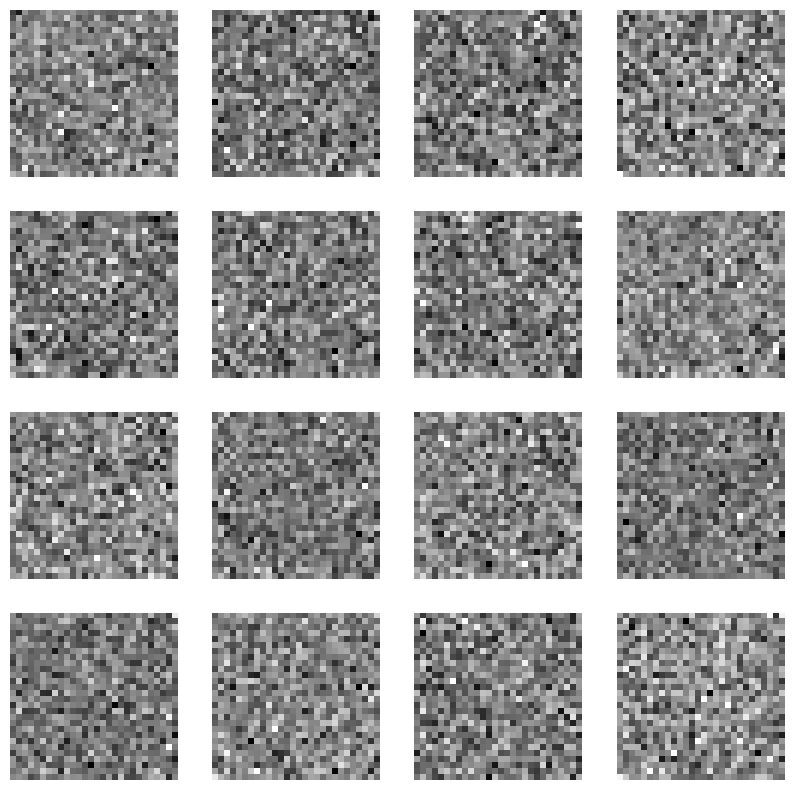

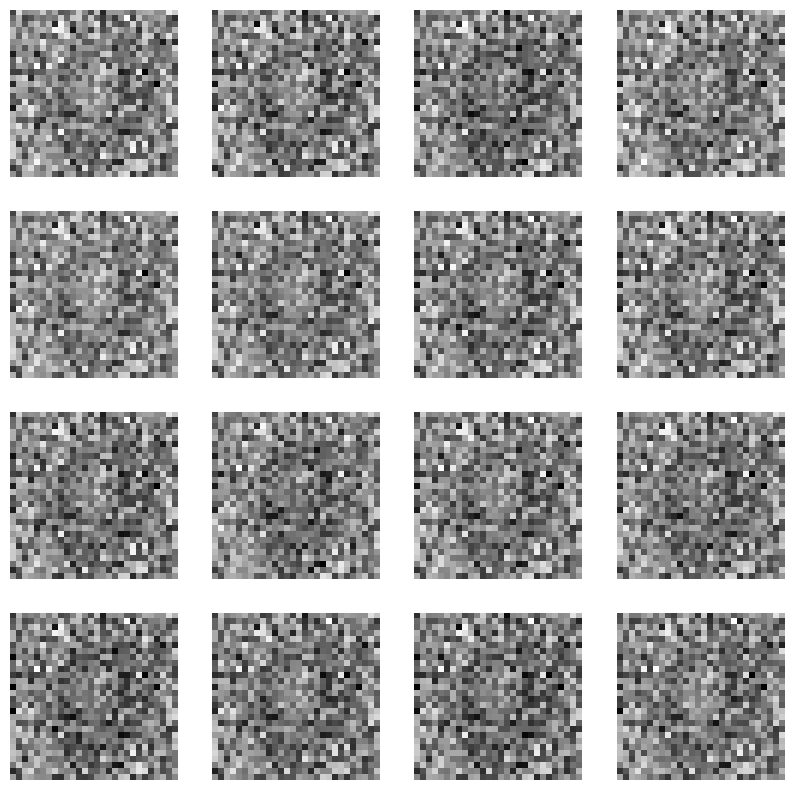

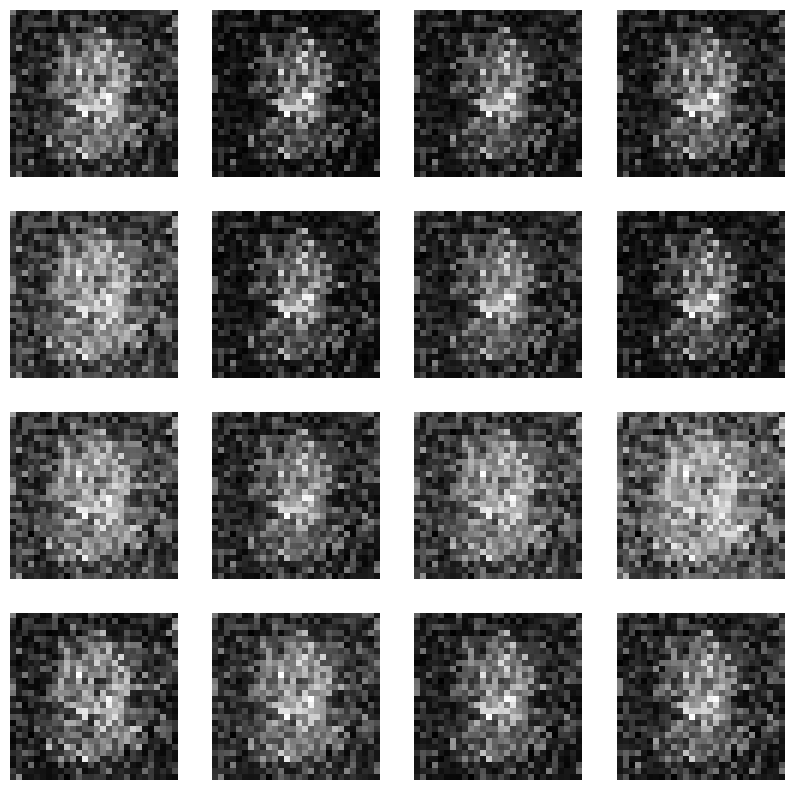

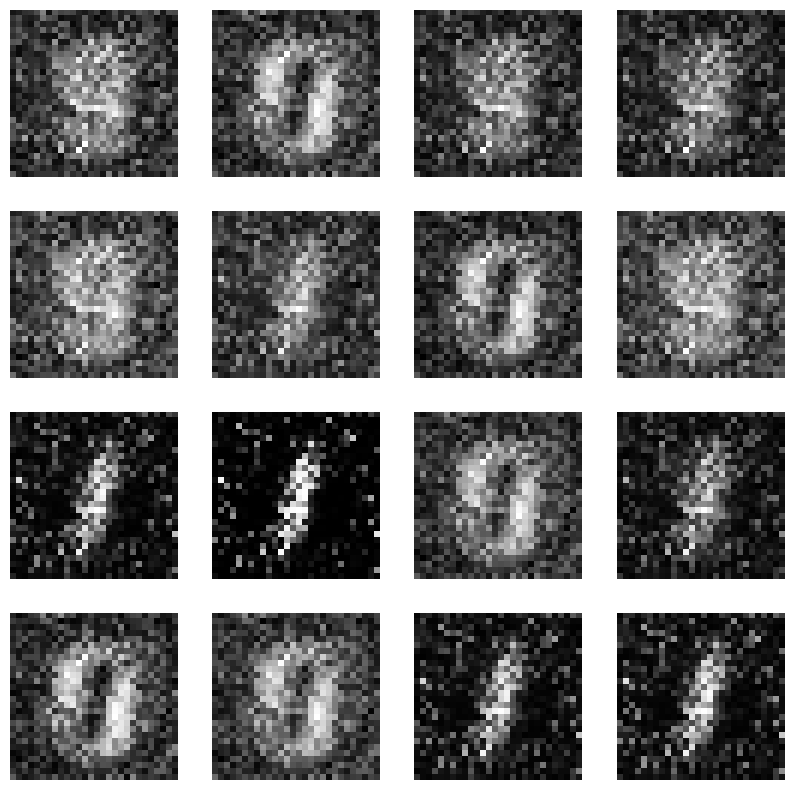

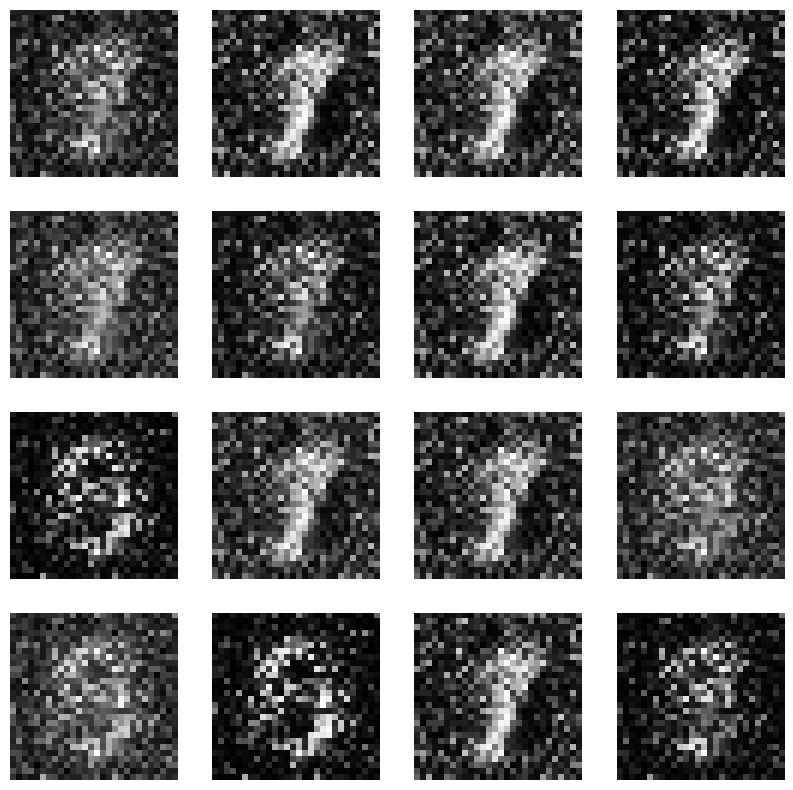

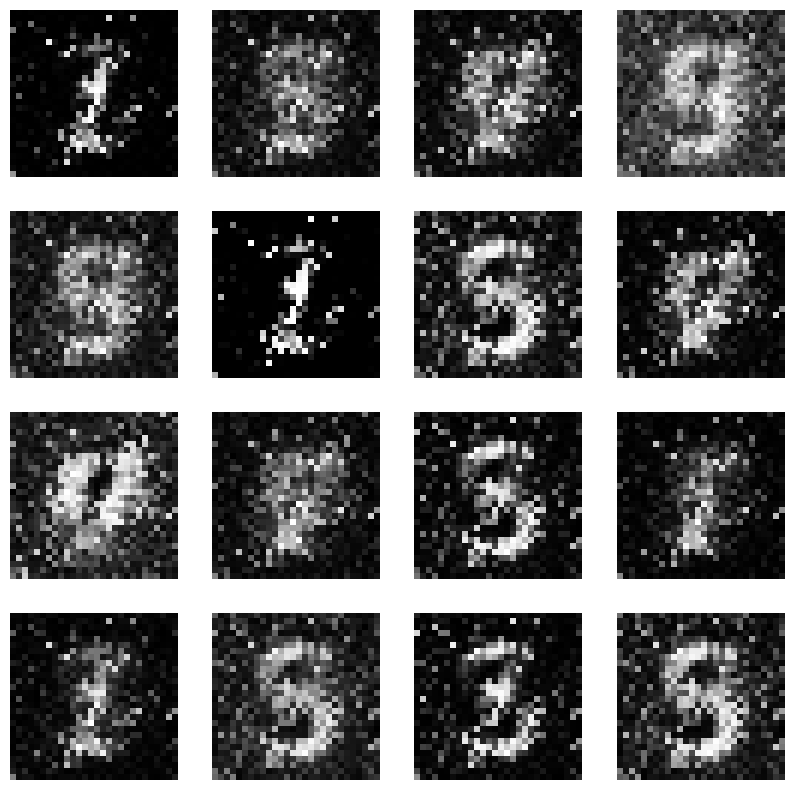

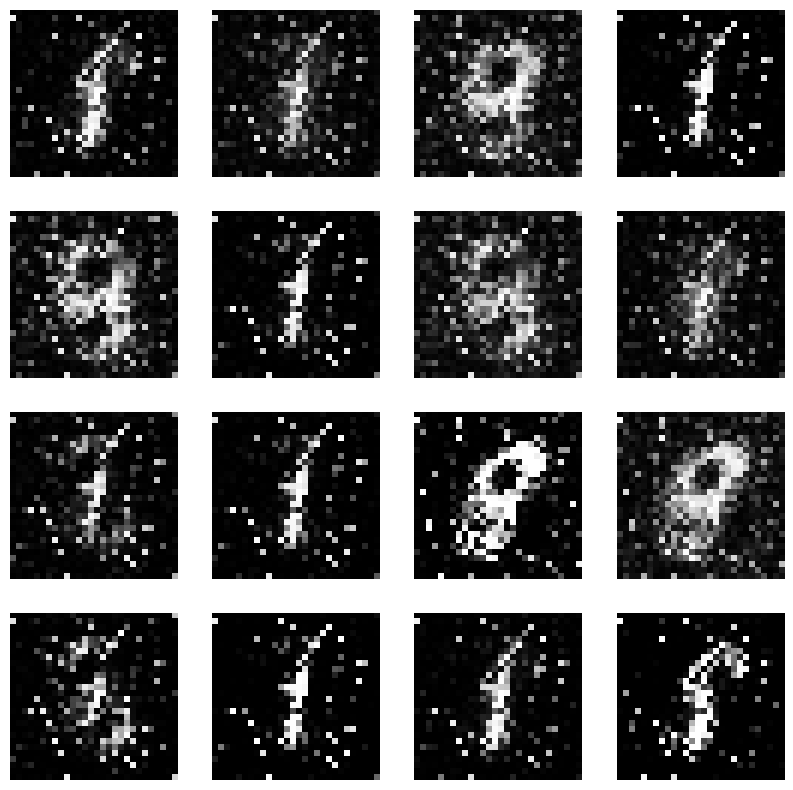

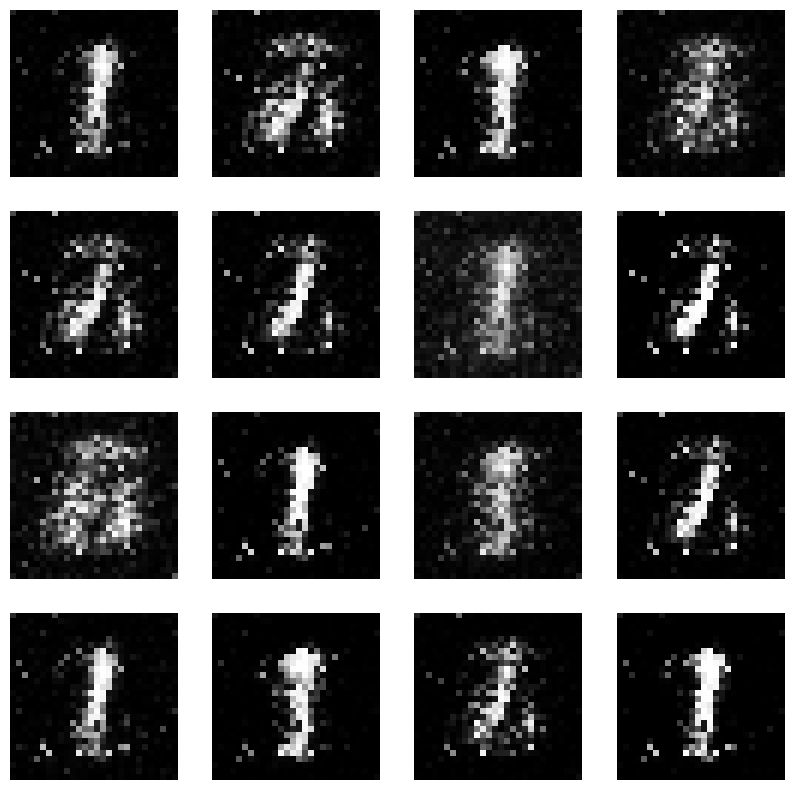

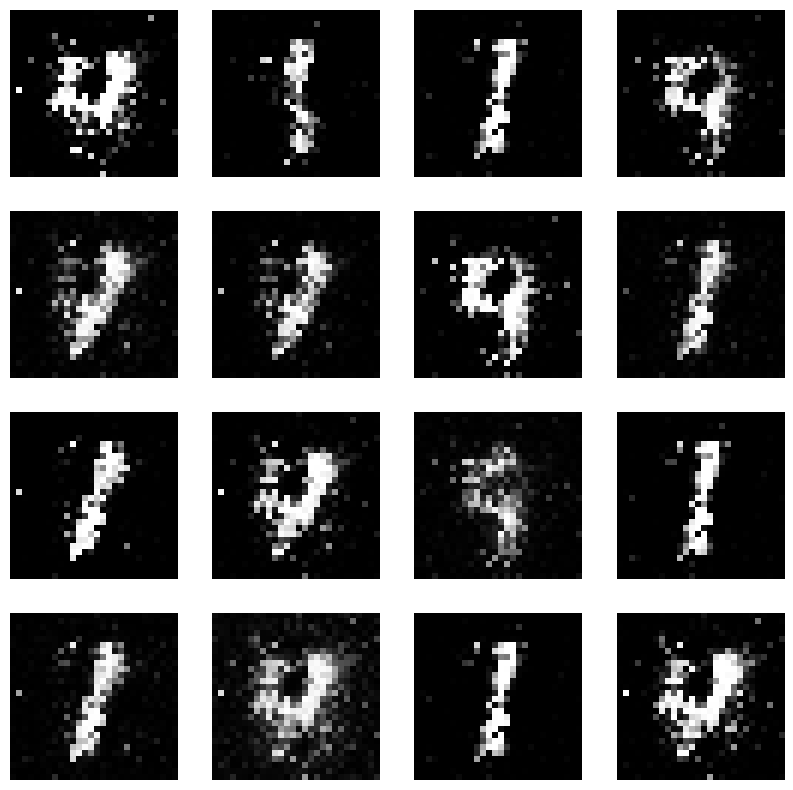

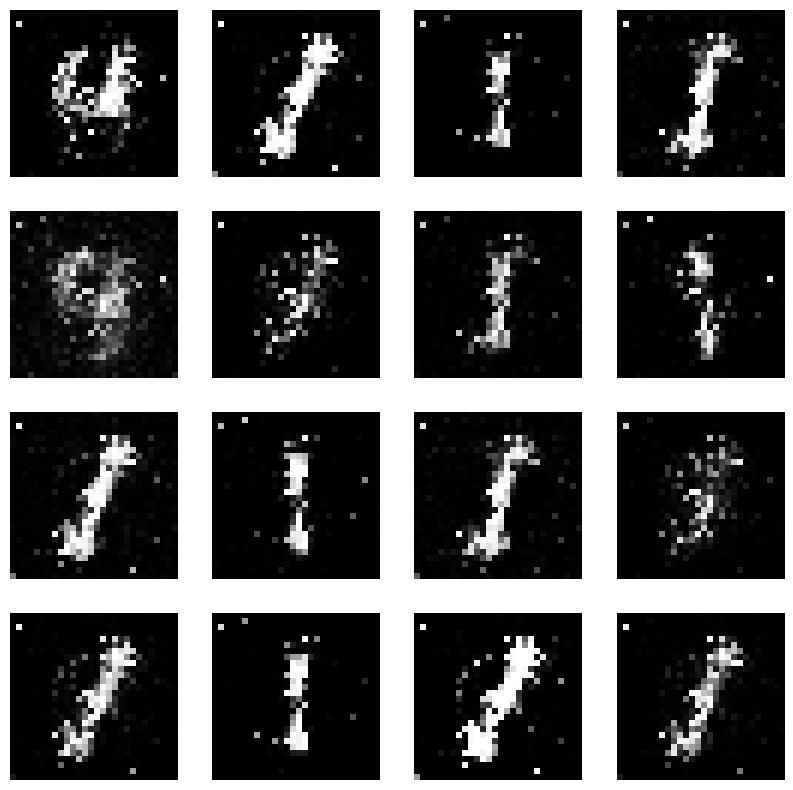

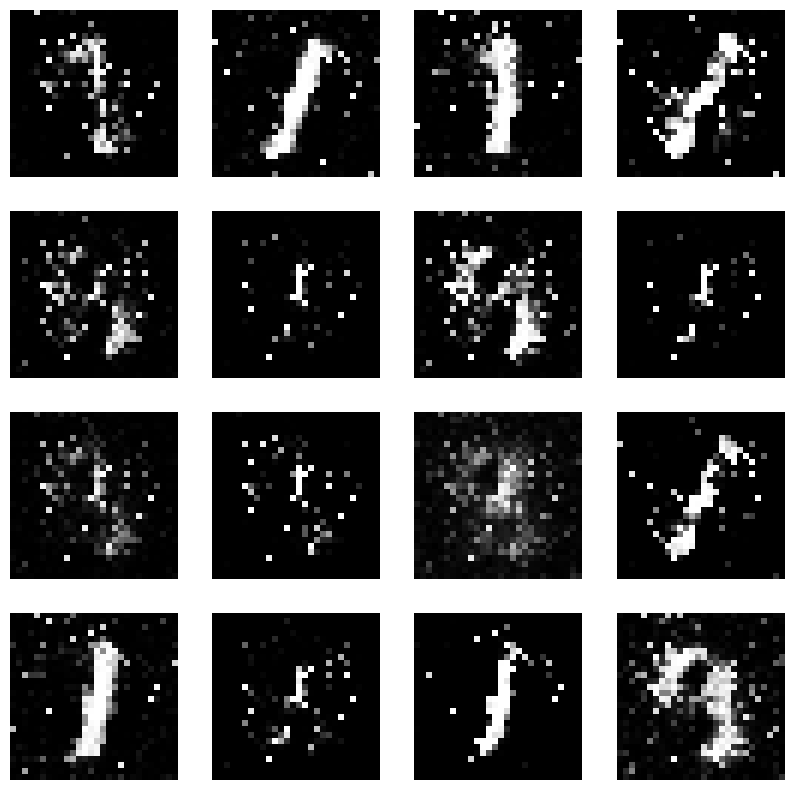

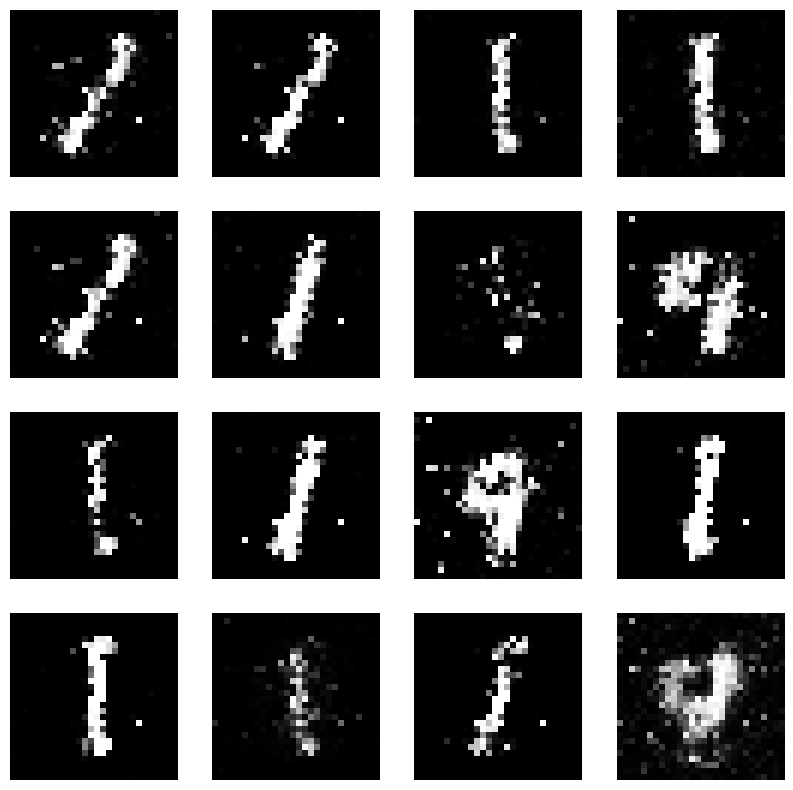

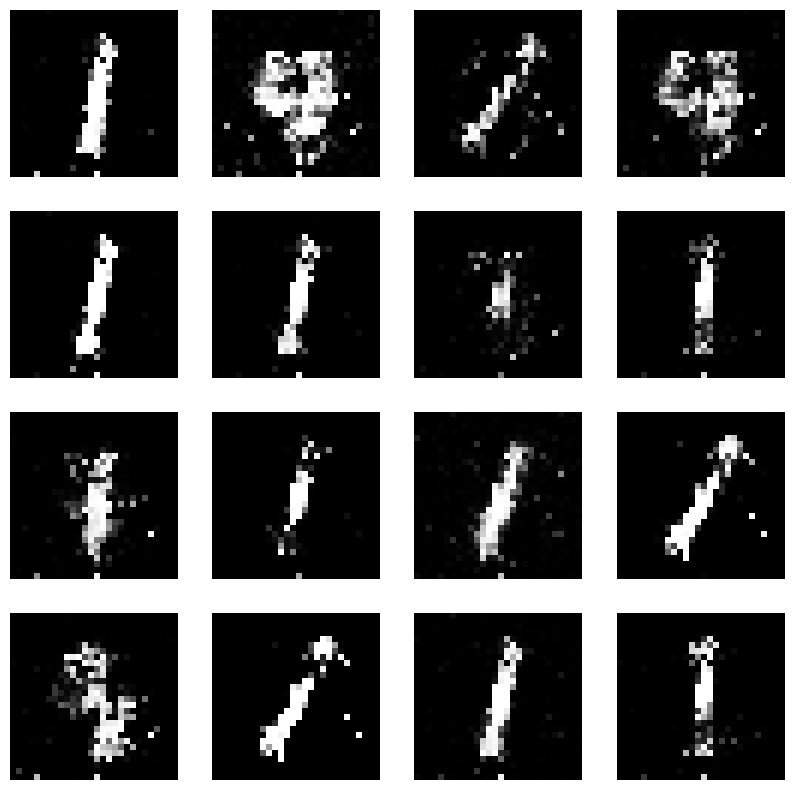

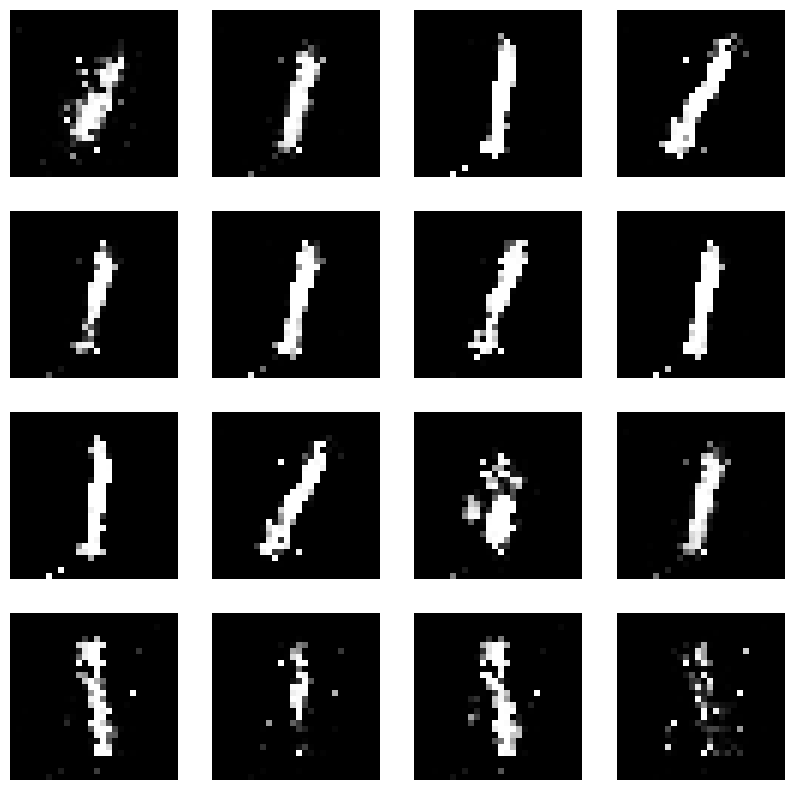

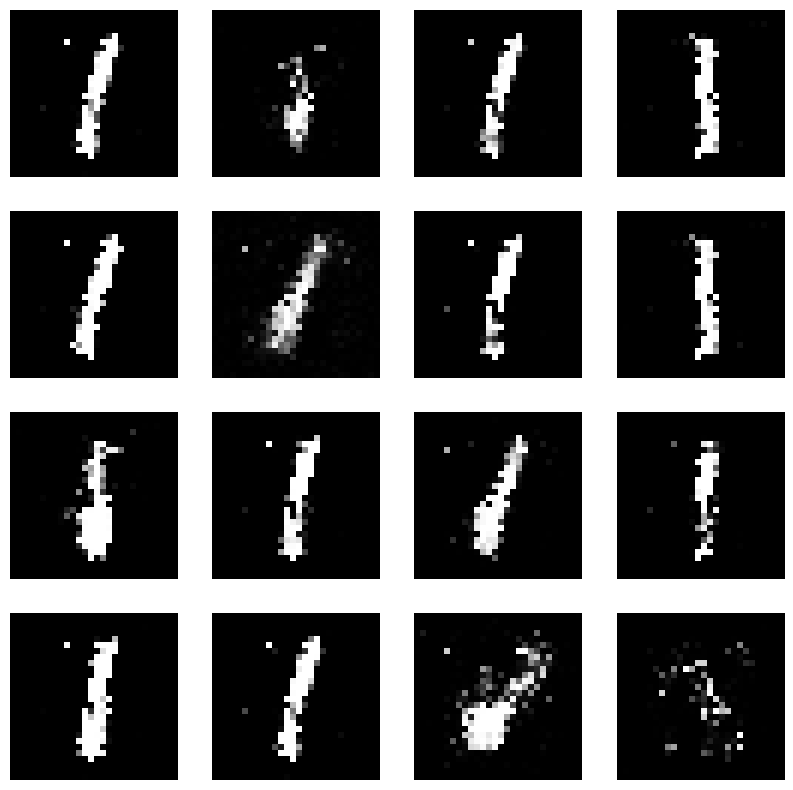

In [15]:
def train_dcgan():
    make_directory_for_run()
    
    #set random seed 
    torch.manual_seed(43)
    #get dataset
    dataloader = prepare_datasets()
    #initalize model
    generator, discriminator = initialize_models()
    loss_function = initialize_loss()
    generator_optimizer, discriminator_optimizer = initialize_optimizers(generator, discriminator)
    
    #train the model 
    for epoch in range(number_of_epochs):
        print(f'Starting epoch {epoch}....')
        perform_epoch(dataloader, generator, discriminator, loss_function, \
            generator_optimizer, discriminator_optimizer, epoch)
    
    print(f'Finished unique run {unique_run_id}')
    
    
if __name__ =='__main__':
    train_dcgan()